In [33]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/nicolelumagui/ML-Exercise_Advertising_Linear-Regression/refs/heads/master/IPYNB%20and%20Dataset/Advertising.csv')

In [34]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [35]:
# Configuración para mejorar la visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

In [5]:
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


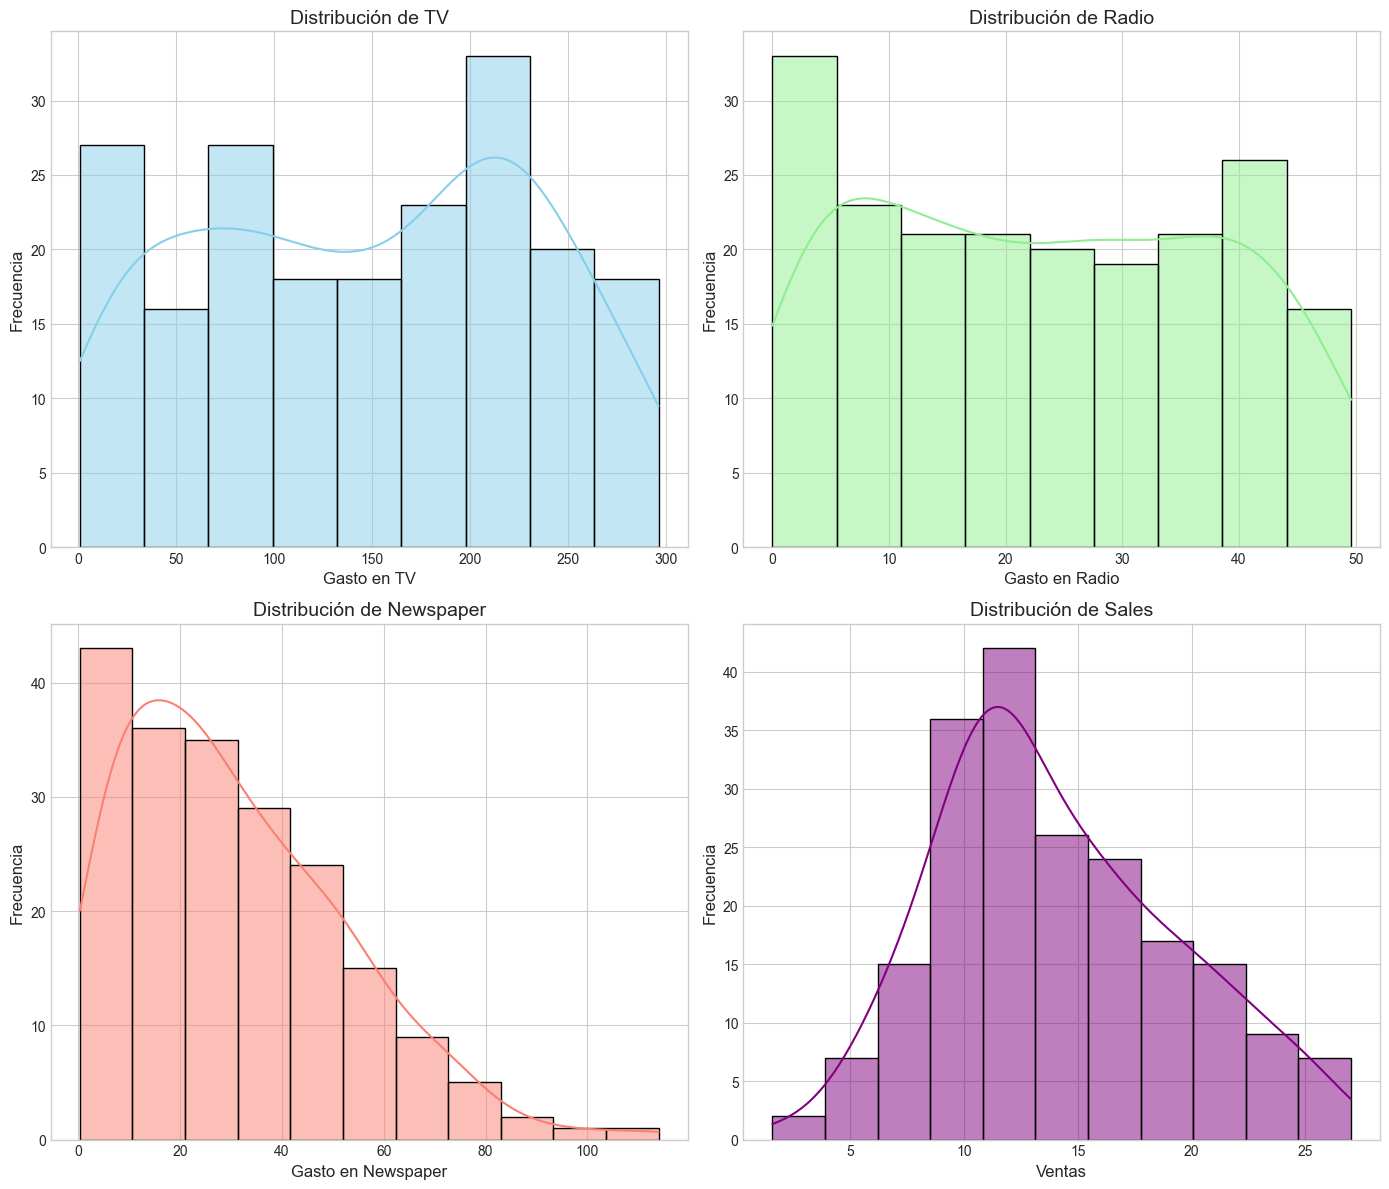

In [36]:
# Visualización de la distribución de las variables
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

sns.histplot(data['TV'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de TV')
axes[0].set_xlabel('Gasto en TV')
axes[0].set_ylabel('Frecuencia')

sns.histplot(data['Radio'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Radio')
axes[1].set_xlabel('Gasto en Radio')
axes[1].set_ylabel('Frecuencia')

sns.histplot(data['Newspaper'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribución de Newspaper')
axes[2].set_xlabel('Gasto en Newspaper')
axes[2].set_ylabel('Frecuencia')

sns.histplot(data['Sales'], kde=True, ax=axes[3], color='purple')
axes[3].set_title('Distribución de Sales')
axes[3].set_xlabel('Ventas')
axes[3].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

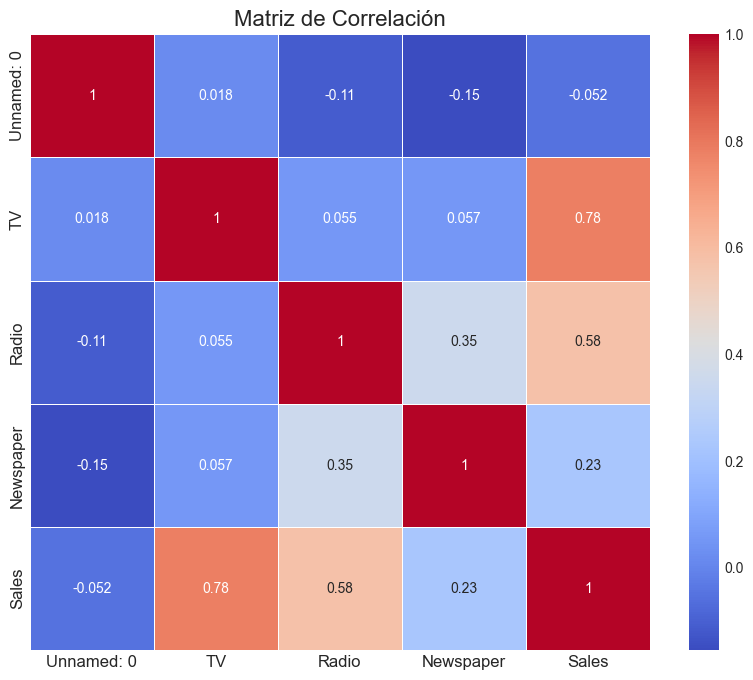

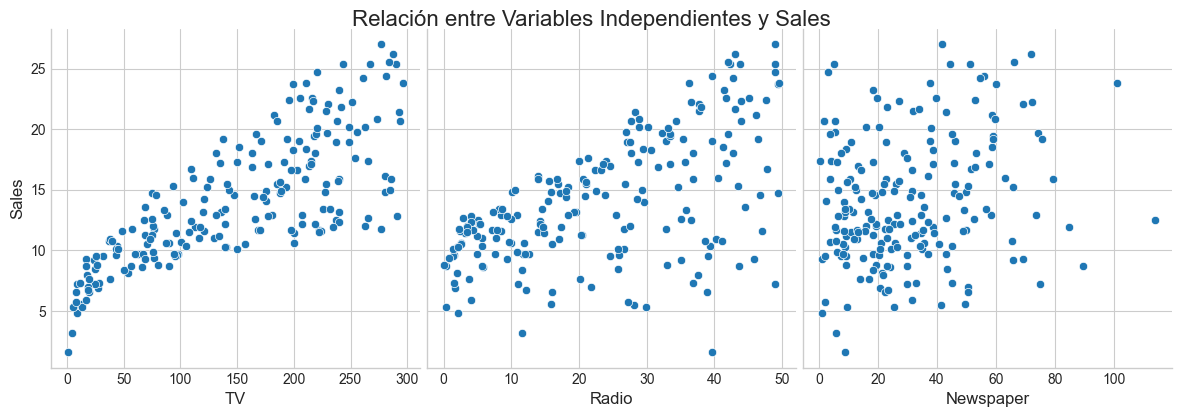

In [37]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Pairplot para visualizar relaciones entre variables
sns.pairplot(data, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.suptitle('Relación entre Variables Independientes y Sales', y=1.02, fontsize=16)
plt.show()

In [40]:
# 3. Preparar los datos para el modelado
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

# División en conjuntos de entrenamiento y validación (80% train, 20% val) con random_state=42
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nConjunto de entrenamiento:", X_train.shape)
print("Conjunto de validación:", X_val.shape)


Conjunto de entrenamiento: (160, 3)
Conjunto de validación: (40, 3)


In [42]:
# Función para evaluar modelos
def evaluar_modelo(y_true, y_pred, nombre_conjunto):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"Evaluación en conjunto de {nombre_conjunto}:")
    print(f"- Error cuadrático medio (MSE): {mse:.4f}")
    print(f"- Raíz del error cuadrático medio (RMSE): {rmse:.4f}")
    print(f"- Error absoluto medio (MAE): {mae:.4f}")
    print(f"- Coeficiente de determinación (R²): {r2:.4f}")
    
    return mse, rmse, mae, r2


MODELO 1: REGRESIÓN LINEAL
Intercepto: 2.979067338122629
Coeficientes:
- TV: 0.044729517468716326
- Radio: 0.18919505423437652
- Newspaper: 0.0027611143413671935

Regresión Lineal:
Evaluación en conjunto de entrenamiento:
- Error cuadrático medio (MSE): 2.7051
- Raíz del error cuadrático medio (RMSE): 1.6447
- Error absoluto medio (MAE): 1.1985
- Coeficiente de determinación (R²): 0.8957
Evaluación en conjunto de validación:
- Error cuadrático medio (MSE): 3.1741
- Raíz del error cuadrático medio (RMSE): 1.7816
- Error absoluto medio (MAE): 1.4608
- Coeficiente de determinación (R²): 0.8994

Ecuación del modelo de regresión lineal:
Sales = 2.9791 + 0.0447 × TV + 0.1892 × Radio + 0.0028 × Newspaper


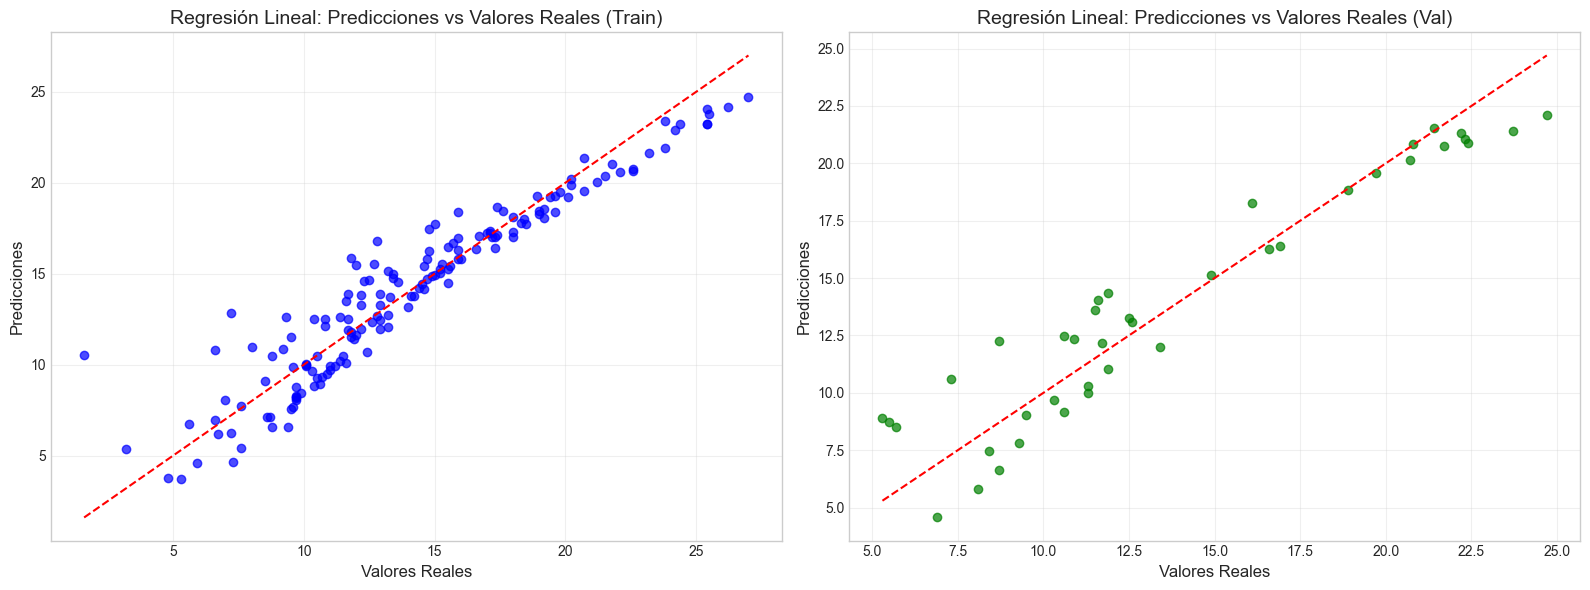

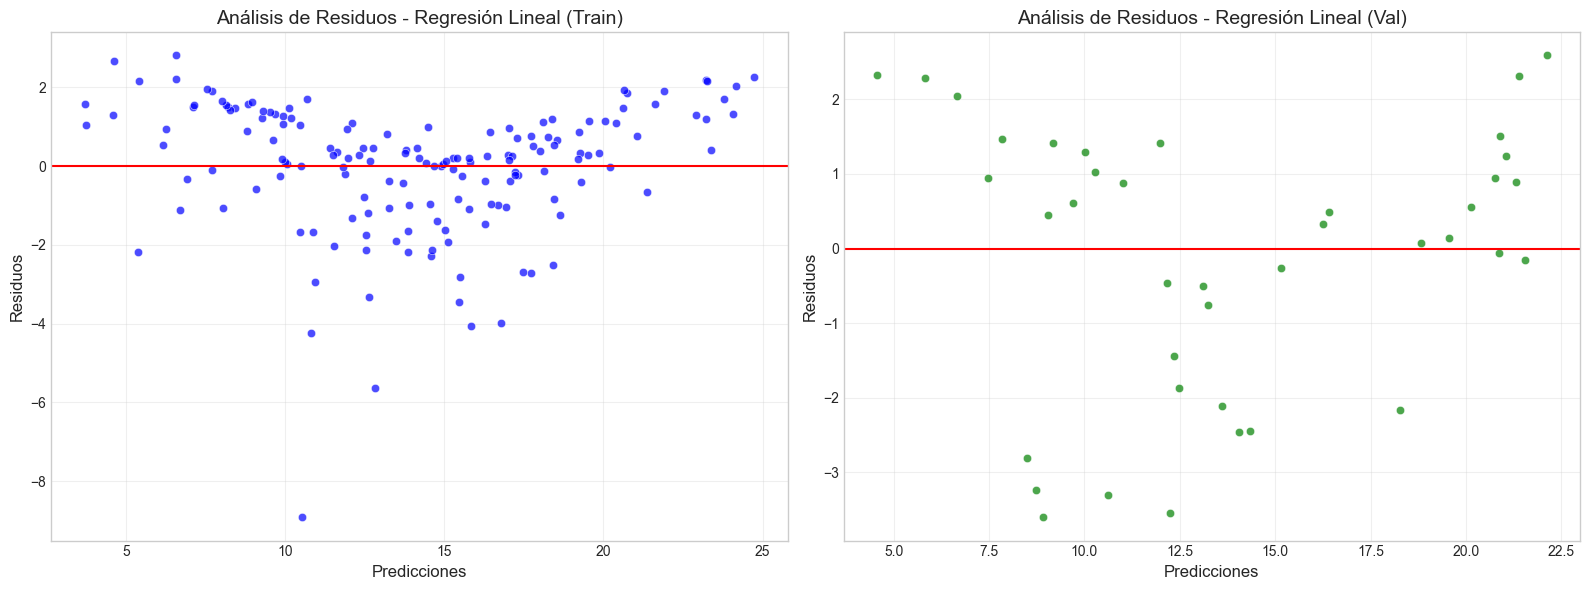

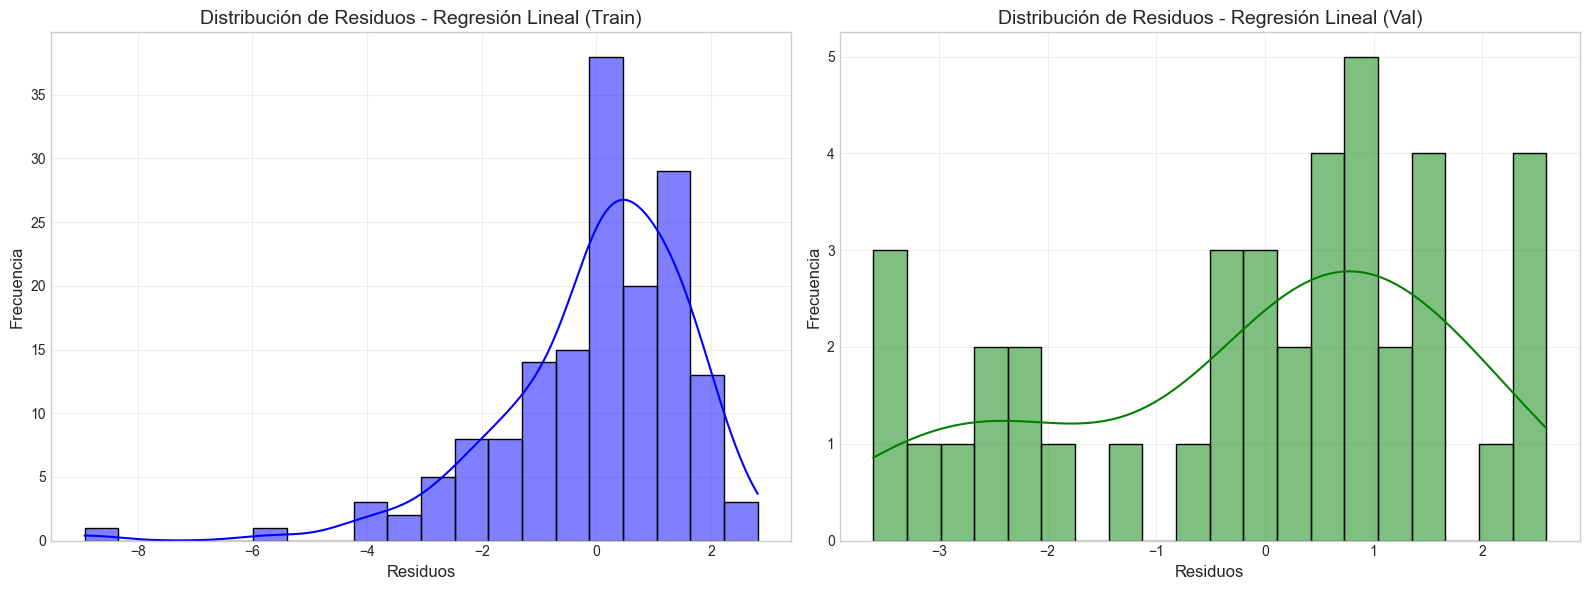

In [43]:
########################################################
# MODELO 1: REGRESIÓN LINEAL
########################################################
print("\n" + "="*50)
print("MODELO 1: REGRESIÓN LINEAL")
print("="*50)

# Entrenamiento
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Coeficientes e intercepto
print("Intercepto:", lr_model.intercept_)
print("Coeficientes:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"- {feature}: {coef}")

# Predicciones
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)

# Evaluación del modelo
print("\nRegresión Lineal:")
_, rmse_train_lr, _, r2_train_lr = evaluar_modelo(y_train, y_train_pred_lr, "entrenamiento")
mse_val_lr, rmse_val_lr, mae_val_lr, r2_val_lr = evaluar_modelo(y_val, y_val_pred_lr, "validación")

# Ecuación del modelo
print("\nEcuación del modelo de regresión lineal:")
equation = f"Sales = {lr_model.intercept_:.4f}"
for i, feature in enumerate(X.columns):
    equation += f" + {lr_model.coef_[i]:.4f} × {feature}"
print(equation)

# Visualización de predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Entrenamiento
axes[0].scatter(y_train, y_train_pred_lr, alpha=0.7, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Predicciones', fontsize=12)
axes[0].set_title('Regresión Lineal: Predicciones vs Valores Reales (Train)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Validación
axes[1].scatter(y_val, y_val_pred_lr, alpha=0.7, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Predicciones', fontsize=12)
axes[1].set_title('Regresión Lineal: Predicciones vs Valores Reales (Val)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de residuos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuos en conjunto de entrenamiento
residuos_train_lr = y_train - y_train_pred_lr
sns.scatterplot(x=y_train_pred_lr, y=residuos_train_lr, ax=axes[0], color='blue', alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='-')
axes[0].set_xlabel('Predicciones', fontsize=12)
axes[0].set_ylabel('Residuos', fontsize=12)
axes[0].set_title('Análisis de Residuos - Regresión Lineal (Train)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residuos en conjunto de validación
residuos_val_lr = y_val - y_val_pred_lr
sns.scatterplot(x=y_val_pred_lr, y=residuos_val_lr, ax=axes[1], color='green', alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='-')
axes[1].set_xlabel('Predicciones', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('Análisis de Residuos - Regresión Lineal (Val)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribución de residuos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(residuos_train_lr, kde=True, ax=axes[0], color='blue', bins=20)
axes[0].set_title('Distribución de Residuos - Regresión Lineal (Train)', fontsize=14)
axes[0].set_xlabel('Residuos', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].grid(True, alpha=0.3)

sns.histplot(residuos_val_lr, kde=True, ax=axes[1], color='green', bins=20)
axes[1].set_title('Distribución de Residuos - Regresión Lineal (Val)', fontsize=14)
axes[1].set_xlabel('Residuos', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


MODELO 2: ÁRBOL DE DECISIÓN

Árbol de Decisión:
Evaluación en conjunto de entrenamiento:
- Error cuadrático medio (MSE): 0.0000
- Raíz del error cuadrático medio (RMSE): 0.0000
- Error absoluto medio (MAE): 0.0000
- Coeficiente de determinación (R²): 1.0000
Evaluación en conjunto de validación:
- Error cuadrático medio (MSE): 2.1750
- Raíz del error cuadrático medio (RMSE): 1.4748
- Error absoluto medio (MAE): 0.9850
- Coeficiente de determinación (R²): 0.9311

Importancia de características:
- TV: 0.6078
- Radio: 0.3786
- Newspaper: 0.0136


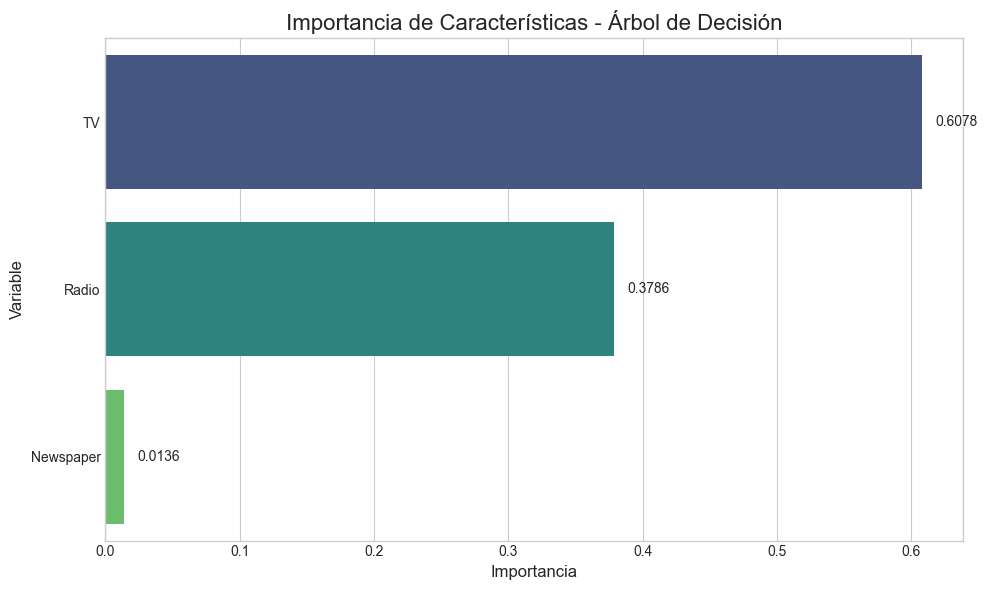

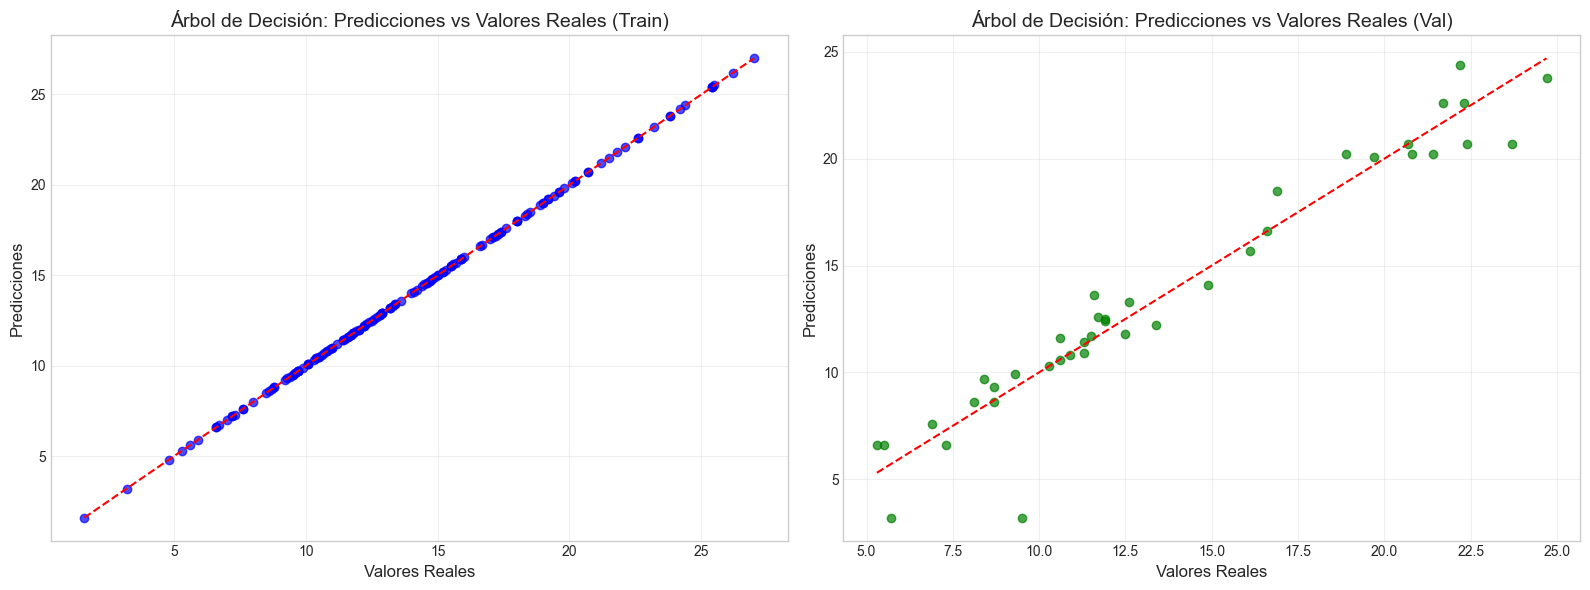

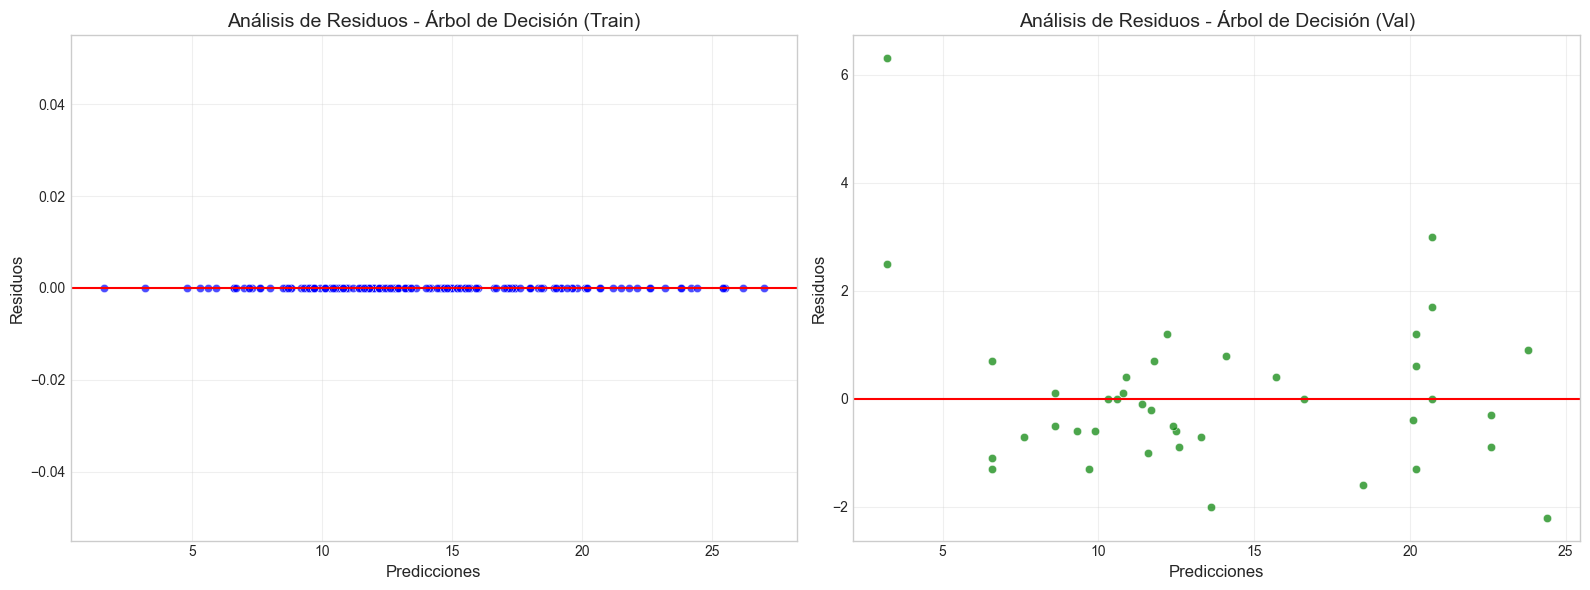

In [44]:
########################################################
# MODELO 2: ÁRBOL DE DECISIÓN
########################################################
print("\n" + "="*50)
print("MODELO 2: ÁRBOL DE DECISIÓN")
print("="*50)

# Entrenamiento
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predicciones
y_train_pred_dt = dt_model.predict(X_train)
y_val_pred_dt = dt_model.predict(X_val)

# Evaluación del modelo
print("\nÁrbol de Decisión:")
_, rmse_train_dt, _, r2_train_dt = evaluar_modelo(y_train, y_train_pred_dt, "entrenamiento")
mse_val_dt, rmse_val_dt, mae_val_dt, r2_val_dt = evaluar_modelo(y_val, y_val_pred_dt, "validación")

# Importancia de características
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})
feature_importance_dt = feature_importance_dt.sort_values('Importance', ascending=False)

print("\nImportancia de características:")
for idx, row in feature_importance_dt.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

# Visualización de importancia de características
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance_dt, palette='viridis')
plt.title('Importancia de Características - Árbol de Decisión', fontsize=16)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Variable', fontsize=12)

# Agregar valores a las barras
for i, v in enumerate(feature_importance_dt['Importance']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Visualización de predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Entrenamiento
axes[0].scatter(y_train, y_train_pred_dt, alpha=0.7, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Predicciones', fontsize=12)
axes[0].set_title('Árbol de Decisión: Predicciones vs Valores Reales (Train)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Validación
axes[1].scatter(y_val, y_val_pred_dt, alpha=0.7, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Predicciones', fontsize=12)
axes[1].set_title('Árbol de Decisión: Predicciones vs Valores Reales (Val)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de residuos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuos en conjunto de entrenamiento
residuos_train_dt = y_train - y_train_pred_dt
sns.scatterplot(x=y_train_pred_dt, y=residuos_train_dt, ax=axes[0], color='blue', alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='-')
axes[0].set_xlabel('Predicciones', fontsize=12)
axes[0].set_ylabel('Residuos', fontsize=12)
axes[0].set_title('Análisis de Residuos - Árbol de Decisión (Train)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residuos en conjunto de validación
residuos_val_dt = y_val - y_val_pred_dt
sns.scatterplot(x=y_val_pred_dt, y=residuos_val_dt, ax=axes[1], color='green', alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='-')
axes[1].set_xlabel('Predicciones', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('Análisis de Residuos - Árbol de Decisión (Val)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


MODELO 3: RANDOM FOREST

Random Forest:
Evaluación en conjunto de entrenamiento:
- Error cuadrático medio (MSE): 0.0947
- Raíz del error cuadrático medio (RMSE): 0.3078
- Error absoluto medio (MAE): 0.2294
- Coeficiente de determinación (R²): 0.9963
Evaluación en conjunto de validación:
- Error cuadrático medio (MSE): 0.5907
- Raíz del error cuadrático medio (RMSE): 0.7686
- Error absoluto medio (MAE): 0.6201
- Coeficiente de determinación (R²): 0.9813

Importancia de características:
- TV: 0.6248
- Radio: 0.3622
- Newspaper: 0.0130


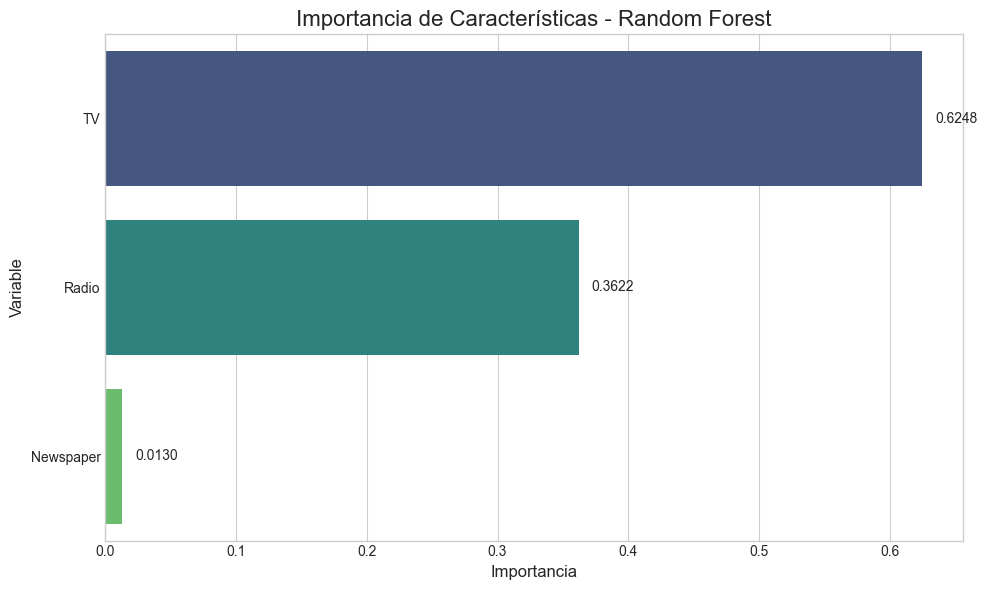

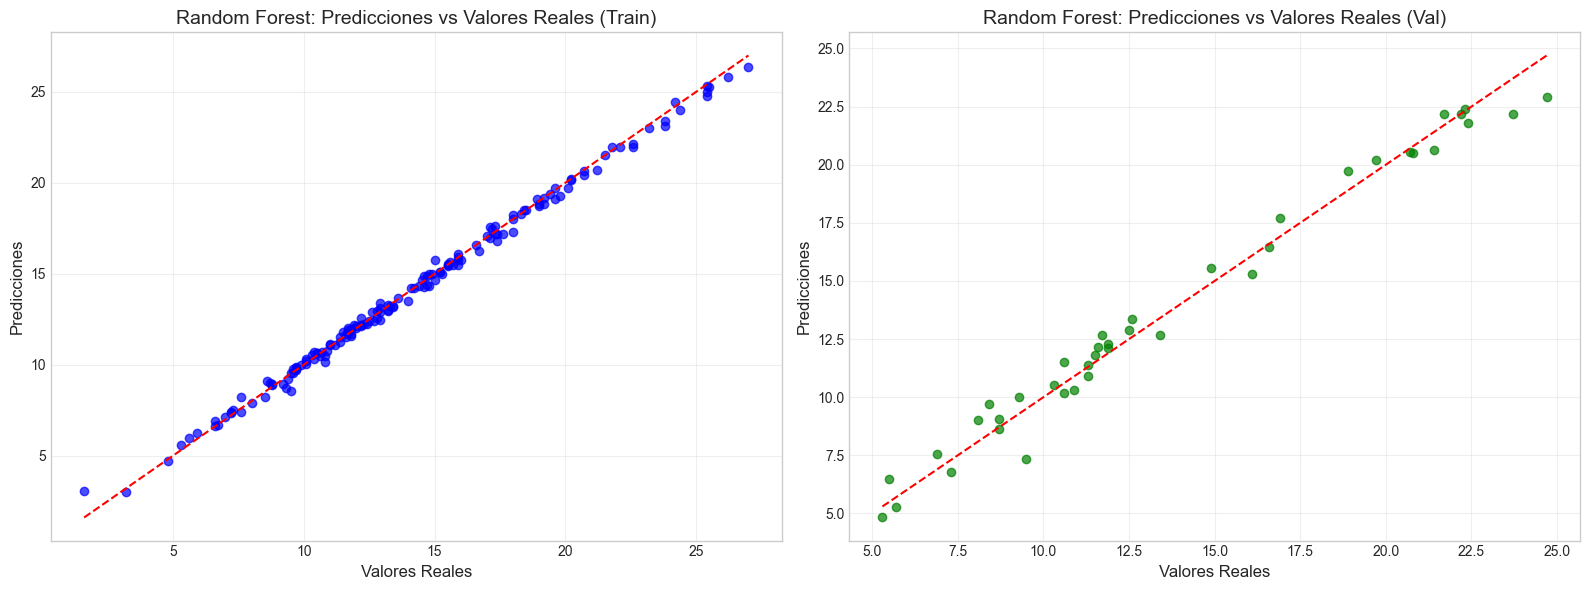

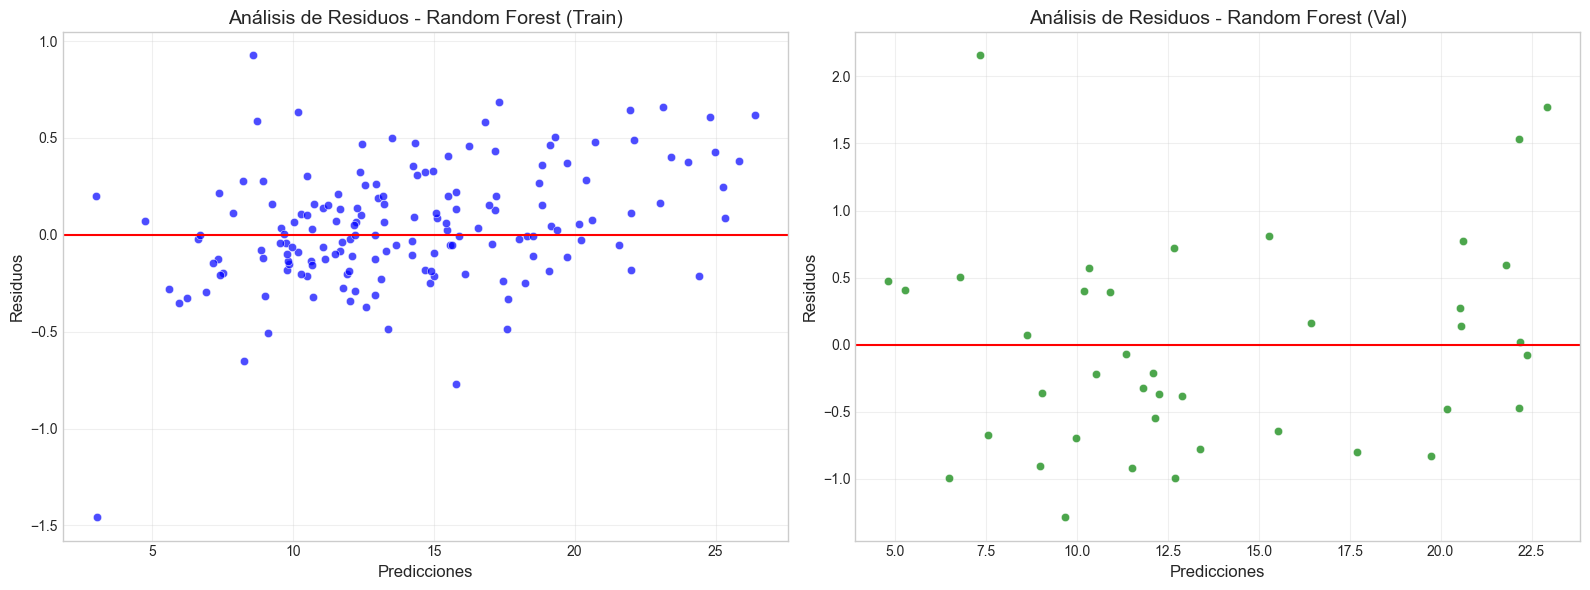

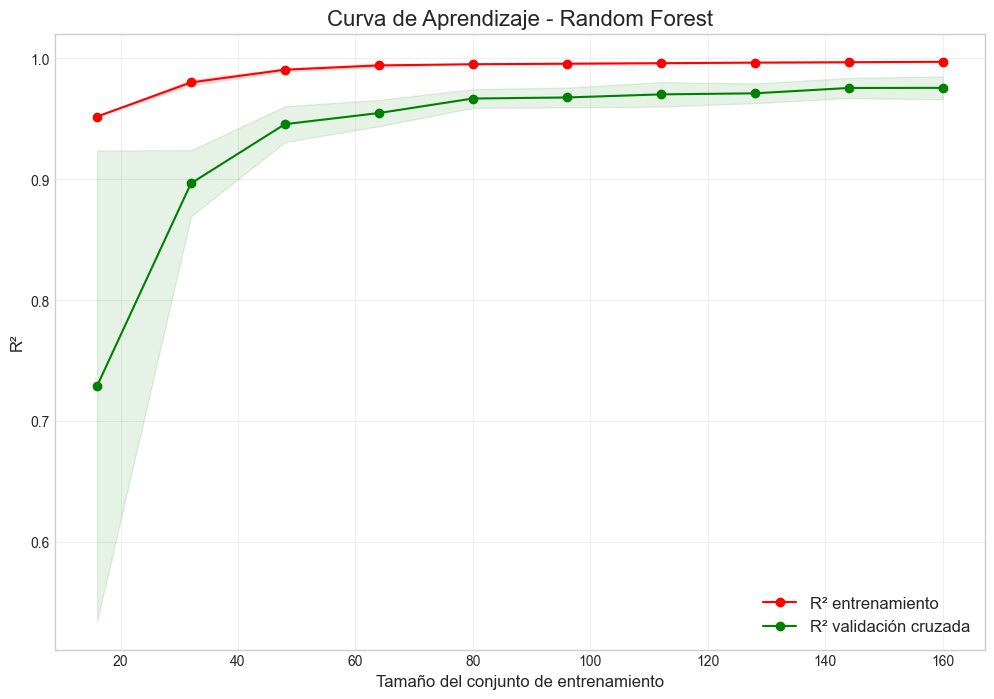

In [45]:
########################################################
# MODELO 3: RANDOM FOREST
########################################################
print("\n" + "="*50)
print("MODELO 3: RANDOM FOREST")
print("="*50)

# Entrenamiento
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)

# Evaluación del modelo
print("\nRandom Forest:")
_, rmse_train_rf, _, r2_train_rf = evaluar_modelo(y_train, y_train_pred_rf, "entrenamiento")
mse_val_rf, rmse_val_rf, mae_val_rf, r2_val_rf = evaluar_modelo(y_val, y_val_pred_rf, "validación")

# Importancia de características
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance_rf = feature_importance_rf.sort_values('Importance', ascending=False)

print("\nImportancia de características:")
for idx, row in feature_importance_rf.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

# Visualización de importancia de características
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance_rf, palette='viridis')
plt.title('Importancia de Características - Random Forest', fontsize=16)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Variable', fontsize=12)

# Agregar valores a las barras
for i, v in enumerate(feature_importance_rf['Importance']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Visualización de predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Entrenamiento
axes[0].scatter(y_train, y_train_pred_rf, alpha=0.7, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Predicciones', fontsize=12)
axes[0].set_title('Random Forest: Predicciones vs Valores Reales (Train)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Validación
axes[1].scatter(y_val, y_val_pred_rf, alpha=0.7, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Predicciones', fontsize=12)
axes[1].set_title('Random Forest: Predicciones vs Valores Reales (Val)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de residuos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuos en conjunto de entrenamiento
residuos_train_rf = y_train - y_train_pred_rf
sns.scatterplot(x=y_train_pred_rf, y=residuos_train_rf, ax=axes[0], color='blue', alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='-')
axes[0].set_xlabel('Predicciones', fontsize=12)
axes[0].set_ylabel('Residuos', fontsize=12)
axes[0].set_title('Análisis de Residuos - Random Forest (Train)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residuos en conjunto de validación
residuos_val_rf = y_val - y_val_pred_rf
sns.scatterplot(x=y_val_pred_rf, y=residuos_val_rf, ax=axes[1], color='green', alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='-')
axes[1].set_xlabel('Predicciones', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('Análisis de Residuos - Random Forest (Val)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Curva de aprendizaje para Random Forest
from sklearn.model_selection import learning_curve

# Calcular curva de aprendizaje para Random Forest
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=100, random_state=42), 
    X, y, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, 
    scoring='r2'
)

# Calcular medias y desviaciones estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Graficar curva de aprendizaje
plt.figure(figsize=(12, 8))
plt.title('Curva de Aprendizaje - Random Forest', fontsize=16)
plt.xlabel('Tamaño del conjunto de entrenamiento', fontsize=12)
plt.ylabel('R²', fontsize=12)
plt.grid(True, alpha=0.3)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_mean, 'o-', color="r", label="R² entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="R² validación cruzada")

plt.legend(loc="best", fontsize=12)
plt.show()


COMPARACIÓN DE MODELOS
              Modelo  RMSE_Train  RMSE_Val  R²_Train    R²_Val   MAE_Val
0   Regresión Lineal    1.644728  1.781600  0.895701  0.899438  1.460757
1  Árbol de Decisión    0.000000  1.474788  1.000000  0.931091  0.985000
2      Random Forest    0.307803  0.768591  0.996347  0.981284  0.620100


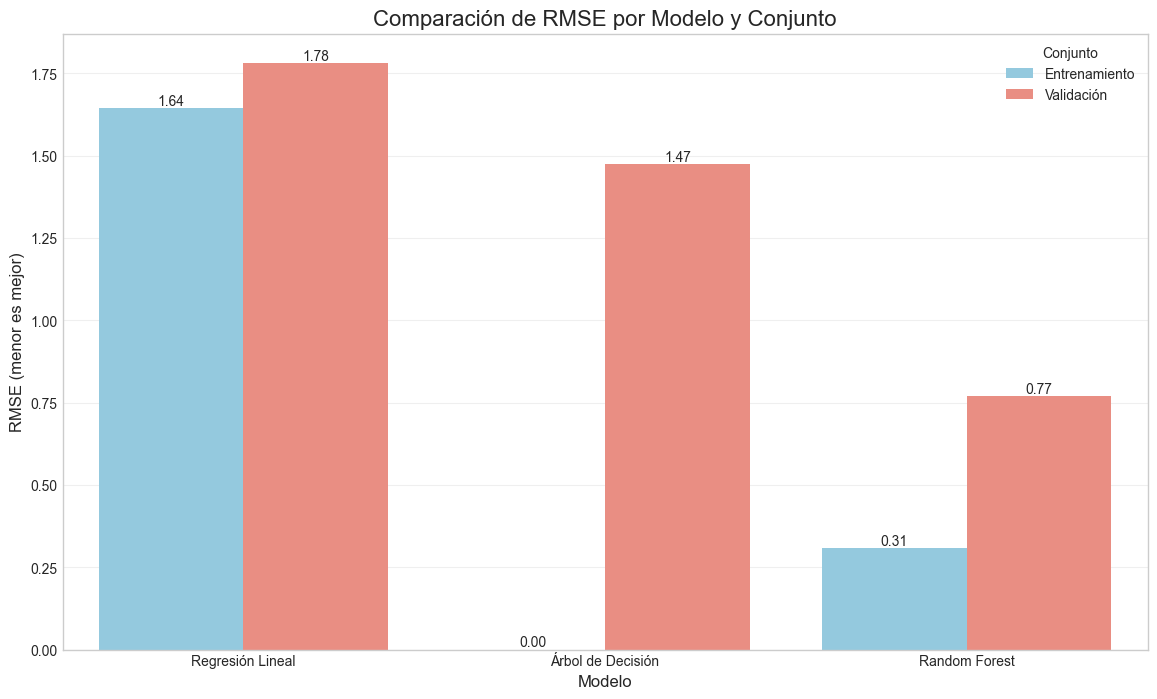

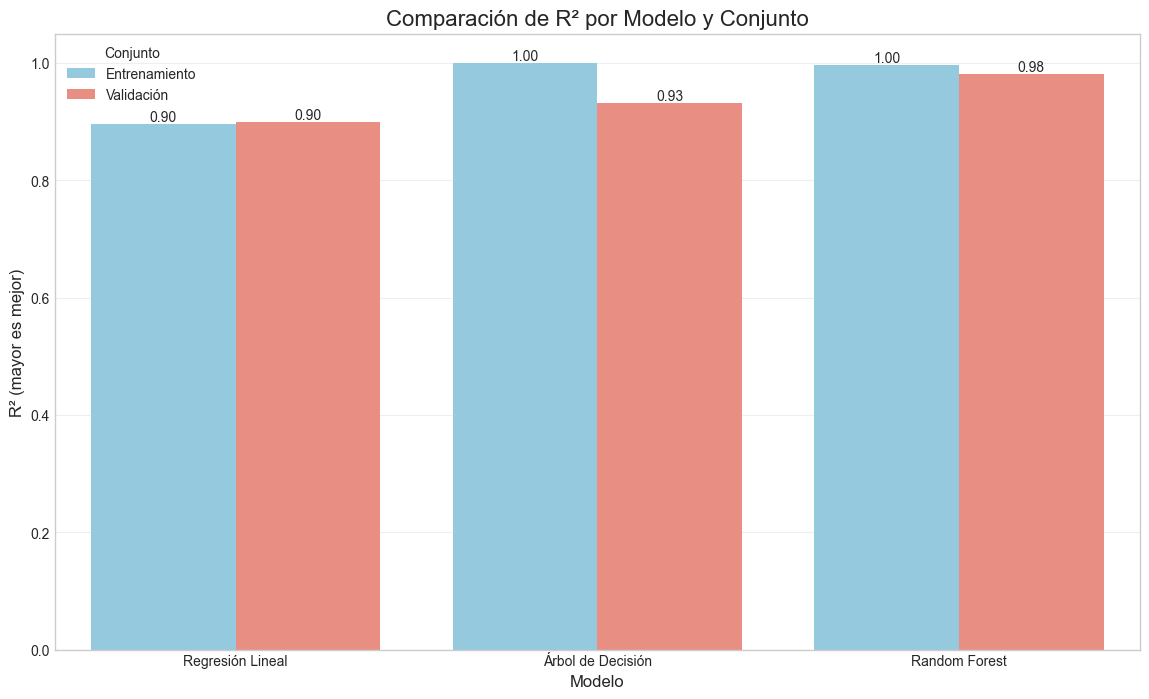


Ejemplo de predicción con nuevos datos:
Datos de entrada:
    TV  Radio  Newspaper
0  200     40         60

Predicción con Regresión Lineal:
Ventas esperadas: 19.66

Predicción con Árbol de Decisión:
Ventas esperadas: 19.00

Predicción con Random Forest:
Ventas esperadas: 20.33

Análisis de sobreajuste:
- Regresión Lineal: Diferencia Train-Val R²: 0.0037 (BAJO riesgo de sobreajuste)
- Árbol de Decisión: Diferencia Train-Val R²: 0.0689 (MEDIO riesgo de sobreajuste)
- Random Forest: Diferencia Train-Val R²: 0.0151 (BAJO riesgo de sobreajuste)

El mejor modelo según R² en validación es: Random Forest (R²=0.9813)


In [46]:
########################################################
# COMPARACIÓN DE MODELOS
########################################################
print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)

# Crear DataFrame para la comparación
comparison_data = {
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'RMSE_Train': [rmse_train_lr, rmse_train_dt, rmse_train_rf],
    'RMSE_Val': [rmse_val_lr, rmse_val_dt, rmse_val_rf],
    'R²_Train': [r2_train_lr, r2_train_dt, r2_train_rf],
    'R²_Val': [r2_val_lr, r2_val_dt, r2_val_rf],
    'MAE_Val': [mae_val_lr, mae_val_dt, mae_val_rf]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

# Visualización de comparación - RMSE
plt.figure(figsize=(14, 8))
comparison_rmse = pd.melt(comparison_df, 
                        id_vars=['Modelo'], 
                        value_vars=['RMSE_Train', 'RMSE_Val'],
                        var_name='Conjunto', 
                        value_name='RMSE')

# Reemplazar nombres para legibilidad
comparison_rmse['Conjunto'] = comparison_rmse['Conjunto'].replace({
    'RMSE_Train': 'Entrenamiento',
    'RMSE_Val': 'Validación'
})

ax = sns.barplot(x='Modelo', y='RMSE', hue='Conjunto', data=comparison_rmse, palette=['skyblue', 'salmon'])
plt.title('Comparación de RMSE por Modelo y Conjunto', fontsize=16)
plt.ylabel('RMSE (menor es mejor)', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.legend(title='Conjunto', fontsize=10)

# Agregar valores a las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.show()

# Visualización de comparación - R²
plt.figure(figsize=(14, 8))
comparison_r2 = pd.melt(comparison_df, 
                       id_vars=['Modelo'], 
                       value_vars=['R²_Train', 'R²_Val'],
                       var_name='Conjunto', 
                       value_name='R²')

# Reemplazar nombres para legibilidad
comparison_r2['Conjunto'] = comparison_r2['Conjunto'].replace({
    'R²_Train': 'Entrenamiento',
    'R²_Val': 'Validación'
})

ax = sns.barplot(x='Modelo', y='R²', hue='Conjunto', data=comparison_r2, palette=['skyblue', 'salmon'])
plt.title('Comparación de R² por Modelo y Conjunto', fontsize=16)
plt.ylabel('R² (mayor es mejor)', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.legend(title='Conjunto', fontsize=10)

# Agregar valores a las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.show()

# Ejemplo de predicción con nuevos datos
print("\nEjemplo de predicción con nuevos datos:")
nuevos_datos = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [60]
})
print("Datos de entrada:")
print(nuevos_datos)

print("\nPredicción con Regresión Lineal:")
print(f"Ventas esperadas: {lr_model.predict(nuevos_datos)[0]:.2f}")

print("\nPredicción con Árbol de Decisión:")
print(f"Ventas esperadas: {dt_model.predict(nuevos_datos)[0]:.2f}")

print("\nPredicción con Random Forest:")
print(f"Ventas esperadas: {rf_model.predict(nuevos_datos)[0]:.2f}")

# Análisis de sobreajuste
print("\nAnálisis de sobreajuste:")
for idx, row in comparison_df.iterrows():
    diferencia = abs(row['R²_Train'] - row['R²_Val'])
    if diferencia > 0.1:
        estado = "ALTO riesgo de sobreajuste"
    elif diferencia > 0.05:
        estado = "MEDIO riesgo de sobreajuste"
    else:
        estado = "BAJO riesgo de sobreajuste"
    
    print(f"- {row['Modelo']}: Diferencia Train-Val R²: {diferencia:.4f} ({estado})")

# Identificar el mejor modelo según R² en validación
r2_val_valores = comparison_df['R²_Val'].values
mejor_modelo_idx = np.argmax(r2_val_valores)
mejor_modelo = comparison_df.iloc[mejor_modelo_idx]['Modelo']
mejor_r2 = r2_val_valores[mejor_modelo_idx]

print(f"\nEl mejor modelo según R² en validación es: {mejor_modelo} (R²={mejor_r2:.4f})")

In [47]:
########################################################
# CONCLUSIONES
########################################################
print("\n" + "="*50)
print("CONCLUSIONES")
print("="*50)

print(f"1. El mejor modelo para predecir las ventas basadas en gastos de publicidad es {mejor_modelo} con un R² de {mejor_r2:.4f} en el conjunto de validación.")

# Obtener la importancia de características del mejor modelo
if mejor_modelo == 'Regresión Lineal':
    coefs = np.abs(lr_model.coef_)
    variables = X.columns
    orden = np.argsort(-coefs)
    print("\n2. Importancia de variables (según magnitud de coeficientes en Regresión Lineal):")
    for i in orden:
        print(f"   - {variables[i]}: {coefs[i]:.4f}")
elif mejor_modelo == 'Árbol de Decisión':
    print("\n2. Importancia de variables (según Árbol de Decisión):")
    for idx, row in feature_importance_dt.iterrows():
        print(f"   - {row['Feature']}: {row['Importance']:.4f}")
else:  # Random Forest
    print("\n2. Importancia de variables (según Random Forest):")
    for idx, row in feature_importance_rf.iterrows():
        print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print("\n3. Análisis de los resultados:")
print("   - Los modelos muestran que los gastos en publicidad tienen una relación significativa con las ventas.")
if mejor_modelo == 'Regresión Lineal':
    print("   - La relación entre las variables de publicidad y las ventas puede ser modelada linealmente con buena precisión.")
else:
    print("   - Las relaciones entre las variables de publicidad y las ventas muestran patrones no lineales que son mejor capturados por modelos basados en árboles.")

print("\n4. Recomendaciones para inversión en publicidad:")
if 'TV' in feature_importance_rf.iloc[0]['Feature'] or 'TV' in feature_importance_dt.iloc[0]['Feature'] or np.abs(lr_model.coef_[0]) > np.abs(lr_model.coef_[1]) and np.abs(lr_model.coef_[0]) > np.abs(lr_model.coef_[2]):
    print("   - Priorizar la inversión en publicidad en TV, ya que muestra el mayor impacto en las ventas.")
elif 'Radio' in feature_importance_rf.iloc[0]['Feature'] or 'Radio' in feature_importance_dt.iloc[0]['Feature'] or np.abs(lr_model.coef_[1]) > np.abs(lr_model.coef_[0]) and np.abs(lr_model.coef_[1]) > np.abs(lr_model.coef_[2]):
    print("   - Priorizar la inversión en publicidad en Radio, ya que muestra el mayor impacto en las ventas.")
else:
    print("   - Priorizar la inversión en publicidad en Newspaper, ya que muestra el mayor impacto en las ventas.")

print("\n5. Limitaciones del análisis:")
print("   - El dataset es relativamente pequeño, lo que puede afectar la generalización de los modelos.")
print("   - No se consideran factores temporales o estacionales que podrían afectar la relación entre publicidad y ventas.")
print("   - Los modelos no capturan posibles efectos sinérgicos entre diferentes canales de publicidad.")

print("\n6. Posibles mejoras:")
print("   - Recopilar más datos para mejorar la robustez de los modelos.")
print("   - Incorporar variables adicionales como temporada, región geográfica o demografía del mercado objetivo.")
print("   - Explorar modelos más avanzados o técnicas de optimización de hiperparámetros.")



CONCLUSIONES
1. El mejor modelo para predecir las ventas basadas en gastos de publicidad es Random Forest con un R² de 0.9813 en el conjunto de validación.

2. Importancia de variables (según Random Forest):
   - TV: 0.6248
   - Radio: 0.3622
   - Newspaper: 0.0130

3. Análisis de los resultados:
   - Los modelos muestran que los gastos en publicidad tienen una relación significativa con las ventas.
   - Las relaciones entre las variables de publicidad y las ventas muestran patrones no lineales que son mejor capturados por modelos basados en árboles.

4. Recomendaciones para inversión en publicidad:
   - Priorizar la inversión en publicidad en TV, ya que muestra el mayor impacto en las ventas.

5. Limitaciones del análisis:
   - El dataset es relativamente pequeño, lo que puede afectar la generalización de los modelos.
   - No se consideran factores temporales o estacionales que podrían afectar la relación entre publicidad y ventas.
   - Los modelos no capturan posibles efectos sinérg